# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

In [10]:
import numpy as np

x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alphas = [0.1, 1.0, 10.0, 100.0] # Changed to a list of alphas

# Loop through each alpha
for alpha in alphas:
    w = np.linalg.inv(x.T*x + alpha * I)*x.T*y
    w = w.ravel()

    # Compare the results
    print(f"Alpha: {alpha:5.1f} | Weights: {w}")

Alpha:   0.1 | Weights: [[-101.72397081    1.16978757]]
Alpha:   1.0 | Weights: [[-20.59044706   0.71048616]]
Alpha:  10.0 | Weights: [[-2.29106262  0.60688107]]
Alpha: 100.0 | Weights: [[-0.22873     0.59509096]]


## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [11]:
def sgd(x, y, alpha, epochs=10, lr=1e-5):
    w = np.zeros((2, 1))
    for _ in range(epochs):
        for i in range(len(y)):
            error = (x[i] * w) - y[i]
            l1_grad = alpha * np.sign(w)
            l1_grad[0] = 0
            w = w - lr * (x[i].T * error + l1_grad)
    return w

In [12]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alpha = 0.1 


w = sgd(x, y, alpha, epochs=10)
w=w.ravel()

print(w)

[[0.00088956 0.60333151]]


## 3. Extend the Fisher's classifier

Please extend the targets of the ``iris_data`` variable and use it as the $y$.

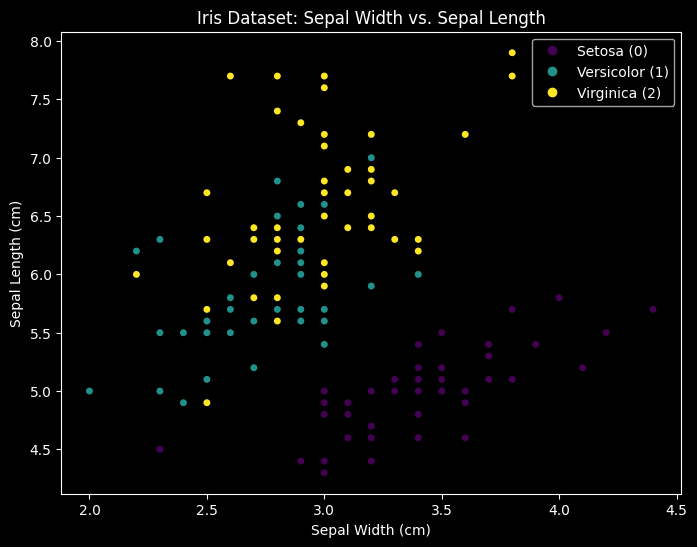

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris_data = load_iris()
iris_df = pd.DataFrame(iris_data.data,columns=iris_data.feature_names)
iris_df.head()

x = iris_df[['sepal width (cm)', 'sepal length (cm)']].values
y = iris_data.target.reshape(-1, 1)

dataset_size = np.size(x)

mean_x, mean_y = np.mean(x), np.mean(y)

SS_xy = np.sum(y * x) - dataset_size * mean_y * mean_x
SS_xx = np.sum(x * x) - dataset_size * mean_x * mean_x

a = SS_xy / SS_xx
b = mean_y - a * mean_x


y_pred = a * x + b

plt.figure(figsize=(8, 6))
scatter = plt.scatter(x[:, 0], x[:, 1], c=y.flatten(), cmap='viridis', edgecolor='k')

plt.xlabel('Sepal Width (cm)')
plt.ylabel('Sepal Length (cm)')
plt.title('Iris Dataset: Sepal Width vs. Sepal Length')

plt.legend(handles=scatter.legend_elements()[0], labels=['Setosa (0)', 'Versicolor (1)', 'Virginica (2)'])
plt.show()